In [7]:
import os

# Habilita leitura de OpenEXR pelo OpenCV
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

import subprocess

import cv2
import numpy as np
import matplotlib.pyplot as plt

import trimesh
import OpenEXR
import Imath


PBRT_WSL_PATH = "/mnt/c/Users/Wemerson/pbrt-v4/build/pbrt"


print("Mesh:", os.path.exists("ClayPot.ply"))
print("Reference:", os.path.exists("vase_reference.tif"))

teste = subprocess.run(
    [
        "wsl",
        PBRT_WSL_PATH,
        "--help"
    ],
    capture_output=True,
    text=True
)


print("PBRT funcionando:",
      "usage: pbrt" in teste.stdout)


Mesh: True
Reference: True
PBRT funcionando: False


In [8]:
def windows_to_wsl(path):

    path = os.path.abspath(path)

    return (
        "/mnt/c" +
        path.replace("\\", "/")[2:]
    )


# teste
print(windows_to_wsl("temp_vessel_scene.pbrt"))

/mnt/c/Users/Wemerson/Downloads/OrenNayar (ipynb)/temp_vessel_scene.pbrt


In [9]:
scene_vessel = r'''
LookAt 
    0.0 0.3 0.055
    0 0 0.055
    0 0 1


Camera "perspective"
    "float fov" [35]


Sampler "halton"
    "integer pixelsamples" [16]


Integrator "path"
    "integer maxdepth" [5]


Film "rgb"
    "string filename" "vessel_render.exr"
    "integer xresolution" [800]
    "integer yresolution" [800]


WorldBegin


# Luz principal lateral/inclinada (Mais potente)
AttributeBegin
    Translate 0.35 0.40 0.20
    AreaLightSource "diffuse"
        "rgb L" [200 200 200]  # Aumentado de 80 para 200
    Shape "sphere"
        "float radius" [0.03]
AttributeEnd

# Luz de preenchimento (Para clarear o lado escuro)
AttributeBegin
    Translate -0.20 0.35 0.05
    AreaLightSource "diffuse"
        "rgb L" [60 60 60]    # Aumentado de 30 para 60
    Shape "sphere"
        "float radius" [0.02]
AttributeEnd


AttributeBegin

    MakeNamedMaterial "oren"

        "string type" "orennayar"

        "rgb reflectance" [0.7 0.4 0.2]

        "float sigma" [30]


    NamedMaterial "oren"


    Shape "plymesh"
        "string filename" "ClayPot.ply"


AttributeEnd
'''


with open("temp_vessel_scene.pbrt","w") as f:
    f.write(scene_vessel)

In [10]:
id="render_vessel_01"
scene_wsl = windows_to_wsl(
    "temp_vessel_scene.pbrt"
)


cmd = [
    "wsl",
    PBRT_WSL_PATH,
    scene_wsl
]


result = subprocess.run(
    cmd,
    capture_output=True,
    text=True
)


# print(result.stdout)
# print(result.stderr)


if result.returncode == 0:
    print("Render concluído com sucesso!")
else:
    print("Erro no PBRT. Código:", result.returncode)

Render concluído com sucesso!


In [11]:
filename = "vessel_render.exr"

exr = OpenEXR.InputFile(filename)

header = exr.header()

dw = header["dataWindow"]

width = dw.max.x - dw.min.x + 1
height = dw.max.y - dw.min.y + 1


pixel_type = Imath.PixelType(Imath.PixelType.FLOAT)


R = np.frombuffer(
    exr.channel("R", pixel_type),
    dtype=np.float32
).reshape(height, width)

G = np.frombuffer(
    exr.channel("G", pixel_type),
    dtype=np.float32
).reshape(height, width)

B = np.frombuffer(
    exr.channel("B", pixel_type),
    dtype=np.float32
).reshape(height, width)


img = np.stack(
    [R, G, B],
    axis=-1
)


print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())


shape: (800, 800, 3)
dtype: float32
min: 0.0
max: 0.515625


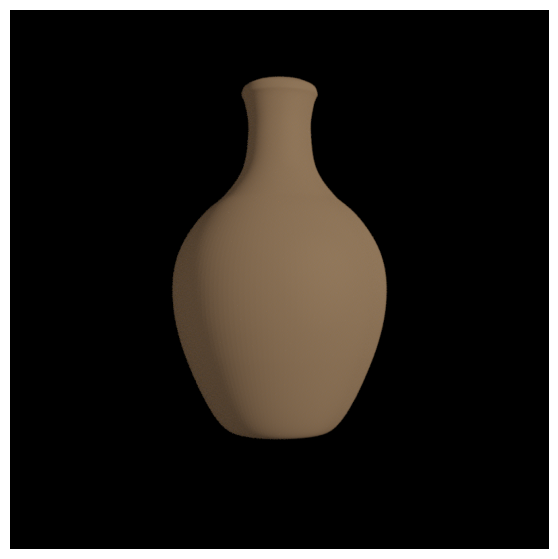

In [12]:
def show_exr(img):

    img_display = np.clip(img,0,None)

    # tone mapping HDR
    img_display = img_display / (1 + img_display)

    # linear -> sRGB aproximado
    img_display = img_display ** (1/2.2)

    plt.figure(figsize=(7,7))
    plt.imshow(img_display)
    plt.axis("off")
    plt.show()

show_exr(img)    

In [13]:
import trimesh

mesh = trimesh.load("ClayPot.ply")


print("Bounds:")
print(mesh.bounds)


print("\nCentro:")
print(mesh.centroid)


print("\nDimensões:")
print(mesh.extents)
    

print("\nMaior dimensão:")
print(mesh.extents.max())

Bounds:
[[-0.03725679 -0.03725679  0.00198155]
 [ 0.03725679  0.03725679  0.1240756 ]]

Centro:
[ 2.04415244e-10 -1.52934055e-10  5.24943367e-02]

Dimensões:
[0.07451358 0.07451358 0.12209404]

Maior dimensão:
0.122094044694677
